In [1]:
from langgraph.graph import StateGraph,START,END
from pydantic import BaseModel

In [2]:
class State(BaseModel):
    number:int
    check_number:str

In [3]:
def check_number(state:State):
    return state

In [4]:
def large_number(state:State):
    return {"check_number":"you number is grater then 10"}

In [5]:
def small_number(state:State):
    return {"check_number":"your number is smaller than 10"}

In [6]:
def route_info(state:State):
    if state.number>=10:
        return "large"
    else:
        return "small"

In [7]:
graph_builder=StateGraph(State)

In [8]:
graph_builder.add_node("check_number",check_number)
graph_builder.add_node("large_number",large_number)
graph_builder.add_node("small_number",small_number)

In [9]:
graph_builder.add_edge(START,"check_number")
graph_builder.add_conditional_edges("check_number",route_info,{"large":"large_number","small":"small_number"})
graph_builder.add_edge("large_number",END)
graph_builder.add_edge("small_number",END)

In [10]:
graph=graph_builder.compile()

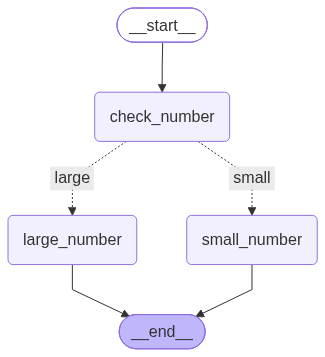

In [11]:
graph

In [15]:
initial_state=State(number=9,check_number="")

In [16]:
result=graph.invoke(initial_state)

In [17]:
print(result)

{'number': 9, 'check_number': 'your number is smaller than 10'}
